<a href="https://colab.research.google.com/github/Kei300/P2-IA-Python-Libraries-Statistics/blob/main/1_Regression_Assumptions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Assumptions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [ ]:
df = pd.read_csv('/content/contaminantes_2026.csv', header=9, on_bad_lines='skip')

In [ ]:
df_tla = df[df['id_station'] == 'TLA'].copy()

df_tla.rename(columns={'value': 'valor'}, inplace=True)
df_tla['date'] = pd.to_datetime(df_tla['date'], errors='coerce')
df_tla['valor'] = pd.to_numeric(df_tla['valor'], errors='coerce')
df_tla.dropna(subset=['date', 'id_parameter', 'valor'], inplace=True)
df_tla.sort_values(by='date', ascending=True, inplace=True)
df_tla.reset_index(drop=True, inplace=True)

display(df_tla.head())
display(df_tla.info())

duplicated_rows = df_tla.duplicated().sum()
print(f"\n Filas duplicadas: {duplicated_rows}")


,date,id_station,id_parameter,valor,unit
0,2026-01-01,TLA,CO,1.15,15
1,2026-01-01,TLA,NO,17.00,1
2,2026-01-01,TLA,NO2,41.00,1
3,2026-01-01,TLA,NOX,59.00,1
4,2026-01-01,TLA,O3,5.00,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38455 entries, 0 to 38454
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          38455 non-null  datetime64[ns]
 1   id_station    38455 non-null  object        
 2   id_parameter  38455 non-null  object        
 3   valor         38455 non-null  float64       
 4   unit          38455 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 1.5+ MB


None


 Filas duplicadas: 0


a) Ajuste de regression lineal para predecir O3 usando NO, NO2, NOX y CO, y reporte R^2 , coeficieciente y sus p-values

In [ ]:
contaminants = ['O3', 'NO', 'NO2', 'NOX', 'CO']
df_regression = df_tla[df_tla['id_parameter'].isin(contaminants)].copy()
df_pivot = df_regression.pivot_table(index='date', columns='id_parameter', values='valor')
df_pivot.dropna(inplace=True)
display(df_pivot.head())
print(f"Shape of regression DataFrame: {df_pivot.shape}")

id_parameter,CO,NO,NO2,NOX,O3
date,,,,,
2026-01-01 00:00:00,1.15,17.0,41.0,59.0,5.0
2026-01-01 01:00:00,0.96,11.0,36.0,46.0,6.0
2026-01-01 02:00:00,0.72,8.0,30.0,38.0,7.0
2026-01-01 03:00:00,0.70,9.0,30.0,39.0,5.0
2026-01-01 04:00:00,0.53,6.0,25.0,31.0,8.0


Shape of regression DataFrame: (3921, 5)


In [ ]:
X = df_pivot[['NO', 'NO2', 'NOX', 'CO']]
y = df_pivot['O3']
modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [ ]:
X_sm = sm.add_constant(X)
modelo_sm = sm.OLS(y, X_sm)
results = modelo_sm.fit()

In [ ]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                     O3   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     356.4
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          5.05e-262
Time:                        03:34:11   Log-Likelihood:                -18019.
No. Observations:                3921   AIC:                         3.605e+04
Df Residuals:                    3916   BIC:                         3.608e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.4932      1.010     46.037      0.0

b) VIF de cada variable

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


In [ ]:
display(vif_data)

,Variable,VIF
0,NO,3044.805108
1,NO2,610.736898
2,NOX,4970.498353
3,CO,6.602461


c) Grafica de residuos vs predichos y Breusch-Pagan

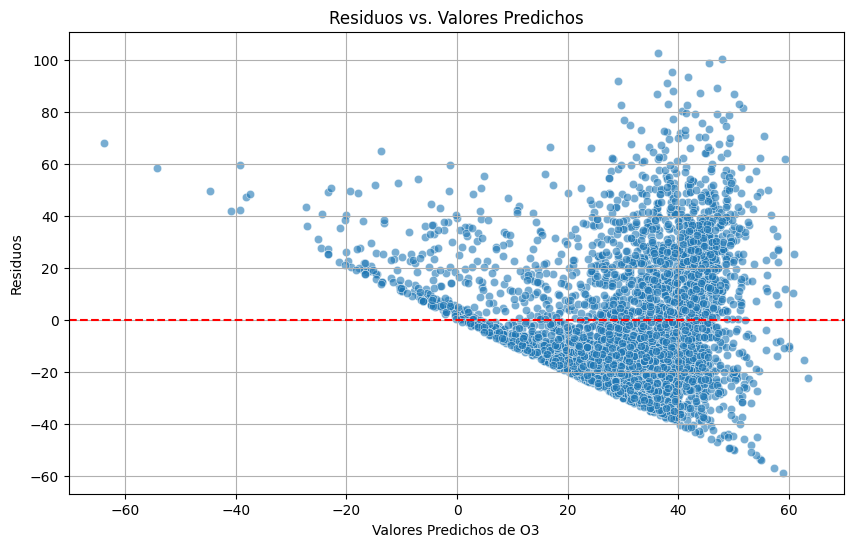

In [ ]:
residuals = results.resid
predicted_values = results.predict()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=predicted_values, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs. Valores Predichos')
plt.xlabel('Valores Predichos de O3')
plt.ylabel('Residuos')
plt.grid(True)
plt.show()


In [ ]:
name = ['Estadístico LM', 'p-valor (LM)', 'Estadístico F', 'p-valor (F)']
bp_test = sm.stats.diagnostic.het_breuschpagan(residuals, X_sm)

print(f"\nResultados de la Prueba de Breusch-Pagan:")
print(f"  {name[0]}: {bp_test[0]:.4f}")
print(f"  {name[1]}: {bp_test[1]:.4e}")
print(f"  {name[2]}: {bp_test[2]:.4f}")
print(f"  {name[3]}: {bp_test[3]:.4e}")


Resultados de la Prueba de Breusch-Pagan:
  Estadístico LM: 210.4806
  p-valor (LM): 2.0941e-44
  Estadístico F: 55.5342
  p-valor (F): 1.2819e-45


d) Grafica residuos en el tiempo y su promedio por hora del día y calculo de Durbin-Watson

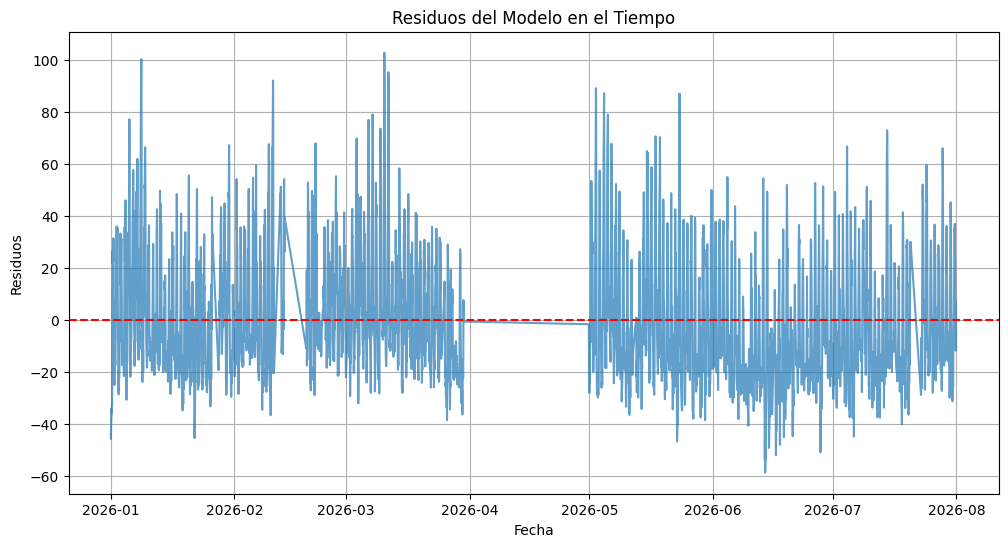

In [ ]:
# 1. Gráfica de Residuos en el Tiempo
plt.figure(figsize=(12, 6))
plt.plot(residuals.index, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos del Modelo en el Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Residuos')
plt.grid(True)
plt.show()


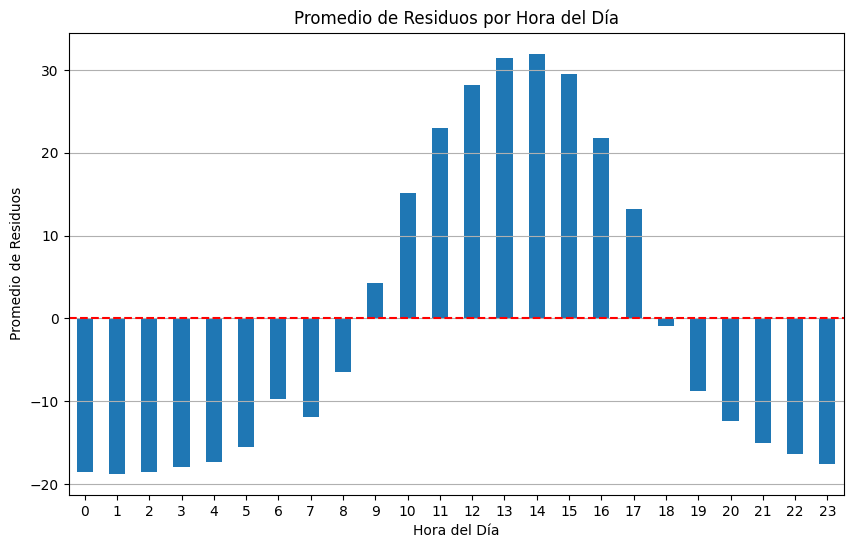

In [ ]:
residuals_df = pd.DataFrame({'date': residuals.index, 'resid': residuals})
residuals_df['hour'] = residuals_df['date'].dt.hour
average_residuals_by_hour = residuals_df.groupby('hour')['resid'].mean()

plt.figure(figsize=(10, 6))
average_residuals_by_hour.plot(kind='bar')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Promedio de Residuos por Hora del Día')
plt.xlabel('Hora del Día')
plt.ylabel('Promedio de Residuos')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

e)QQ-plot de los residuos

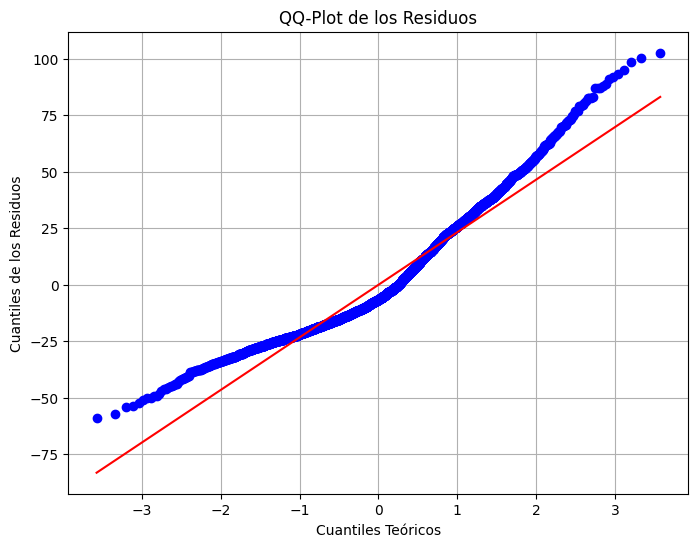

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ-Plot de los Residuos')
plt.xlabel('Cuantiles Teóricos')
plt.ylabel('Cuantiles de los Residuos')
plt.grid(True)
plt.show()

f) ¿Qué supuestos se rompen? ¿Le crees al coeficiente del NAO2 y asu p-value?

**Supuestos que se rompen:**

* **No Multicolinealidad:**
  Los valores del VIF para $NO$ ($3044.8$), $NO_2$ ($610.7$) y $NO_X$ ($4970.5$) es mayor a 10. Esto se debe a que $NO_X$, $NO$ y $NO_2$ tienen mucha colinealidad debido a sus propiedades físicas

* **Homocedasticidad:**
  La prueba de **Breusch-Pagan** entrega un $p\text{-value} = 2.09 \times 10^{-44} < 0.05$. En el gráfico de *Residuos vs. Predichos* se aprecia claramente una dispersión en forma de embudo/abanico. La varianza de los residuales no permanece constante en los niveles de la variante independiente.

* **Independencia :**
  El estadístico de **Durbin-Watson** es $0.222$ (lejano a $2.0$), tiene una fuerte autocorrelación positiva en los errores.

* **Normalidad de los residuos:**
  La prueba de Jarque-Bera ($p\text{-value} = 1.41 \times 10^{-127}$) y el  QQ-plot muestran que los residuos no siguen una distribución normal.

---

**No se le debe creer al coeficiente NO2 y a p-value.**

Existe una gran multicolinealidad en el modelo debido a la presencia simultánea de $NO_X$, $NO_2$ y $NO$. Cuando las variables están tan fuertemente relacionadas entre sí, los errores estándar se inflan demasiado y las estimaciones del modelo se vuelven inestables y erróneas.

Como consecuencia, el modelo entrega un $p\text{-value}$ engañosamente alto ($0.490$). Para corregirlo, se puede eliminar $NO_X$ para romper la redundancia lineal o utilizar modelos no lineales que no sufran por la colinealidad de las variables